# Scipy trial

https://stackoverflow.com/questions/1713335/peak-finding-algorithm-for-python-scipy

https://stackoverflow.com/questions/25571260/scipy-signal-find-peaks-cwt-not-finding-the-peaks-accurately

https://blog.ytotech.com/2015/11/01/findpeaks-in-python/


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, find_peaks_cwt, stft
import IPython

import os
import sys
sys.path.insert(0, os.path.abspath('..'))
from dataprocess.util.data_process import read_snd_file

In [3]:
SOUND_FOLDER = '../data/sound/gh-drone/denoise'
# fn = f'{SOUND_FOLDER}/gh-4_mono_44k_denoised.wav'
# fn = f'{SOUND_FOLDER}/bird-gh4-drone-mix-mono-44100_denoised.wav'
fn = f'{SOUND_FOLDER}/gh4-drone-mix-mono-44100_denoised.wav'
y, sr, dura = read_snd_file(fn, sr=44100, scale=True)
print(f'data shape: {y.shape}, data:\n{y[:20]}')
print(f'sample rate: {sr}')
print(f'duration: {dura}')

print(f'max of y: {np.max(y)}')
IPython.display.display(IPython.display.Audio(data=y, rate=sr))

load ../data/sound/gh-drone/denoise/gh4-drone-mix-mono-44100_denoised.wav sr: 44100 offset: 0.0 duration: 60 mono: True scale: True
data shape: (350208,), data:
[0.0304815  0.03022536 0.0304815  0.03022536 0.03022536 0.03022536
 0.03022536 0.03022536 0.0304815  0.03022536 0.0304815  0.0304815
 0.0304815  0.0304815  0.0304815  0.03022536 0.03022536 0.03022536
 0.03022536 0.03022536]
sample rate: 44100
duration: 7.9412244897959186
max of y: 0.9999998807907104


In [4]:
vector = [
    0, 6, 25, 20, 15, 8, 15, 6, 0, 6, 0, -5, -15, -3, 4, 10, 8, 13, 8, 10, 3,
    1, 20, 7, 3, 0 ]
import scipy.signal
print('Detect peaks without any filters.')
indexes = scipy.signal.find_peaks_cwt(vector, np.arange(1, 4),
    max_distances=np.arange(1, 4)*2)
indexes = np.array(indexes) - 1
print('Peaks are: %s' % (indexes))

Detect peaks without any filters.
Peaks are: [ 2  6  9 17 22]


/tmp/ipykernel_82429/2737918576.py:1: DeprecationWarning: Please use `gaussian_filter1d` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter1d


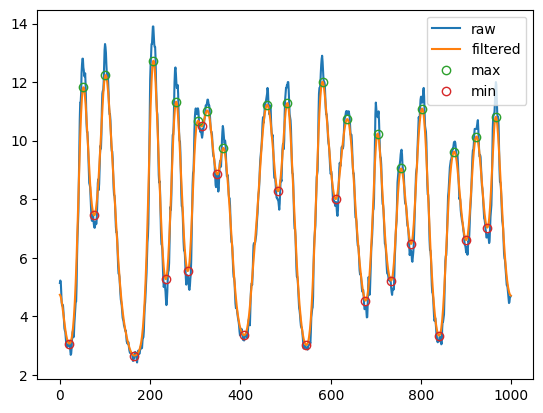

In [5]:
from scipy.ndimage.filters import gaussian_filter1d
from scipy import signal

data =np.array([5.14,5.22,5.16,4.82,4.46,4.36,4.4,4.35,4.13,3.83,3.59,3.51,3.46,3.27,3.08,3.03,2.95,2.96,2.98,3.02,3.09,3.14,3.06,2.84,2.68,2.72,2.92,3.23,3.44,3.5,3.28,3.34,3.73,3.97,4.26,4.48,4.5,5.06,6.02,6.68,7.09,7.58,8.6,9.85,10.7,11.3,11.3,11.6,12.3,12.6,12.8,12.8,12.5,12.4,12.2,12.2,12.3,11.9,11.2,10.6,10.3,10.3,10.,9.53,8.97,8.55,8.49,8.41,8.09,7.71,7.34,7.26,7.42,7.47,7.37,7.17,7.05,7.02,7.09,7.23,7.18,7.16,7.47,7.92,8.55,8.68,8.31,8.52,9.11,9.59,9.83,9.73,10.2,11.1,11.6,11.7,11.7,12.,12.6,13.1,13.3,13.2,13.,12.6,12.3,12.2,12.3,12.,11.6,11.1,10.9,10.9,10.7,10.3,9.83,9.64,9.63,9.37,8.88,8.39,8.14,8.12,7.92,7.48,7.06,6.87,6.87,6.63,6.17,5.71,5.45,5.45,5.34,5.05,4.78,4.57,4.47,4.37,4.16,3.95,3.88,3.83,3.69,3.64,3.57,3.5,3.51,3.33,3.14,3.09,3.06,3.12,3.11,2.94,2.83,2.76,2.74,2.77,2.75,2.73,2.72,2.59,2.47,2.53,2.54,2.63,2.76,2.78,2.75,2.69,2.54,2.42,2.58,2.79,2.83,2.78,2.71,2.77,2.88,2.97,2.97,2.9,2.92,3.16,3.29,3.28,3.49,3.97,4.32,4.49,4.82,5.08,5.48,6.03,6.52,6.72,7.16,8.18,9.52,10.9,12.1,12.6,12.9,13.3,13.3,13.6,13.9,13.9,13.6,13.3,13.2,13.2,12.8,12.,11.4,11.,10.9,10.4,9.54,8.83,8.57,8.61,8.24,7.54,6.82,6.46,6.43,6.26,5.78,5.29,5.,5.08,5.14,5.,4.84,4.56,4.38,4.52,4.84,5.33,5.52,5.56,5.82,6.54,7.27,7.74,7.64,8.14,8.96,9.7,10.2,10.2,10.5,11.3,12.,12.4,12.5,12.3,12.,11.8,11.8,11.9,11.6,11.,10.3,10.,9.98,9.6,8.87,8.16,7.76,7.74,7.54,7.03,6.54,6.25,6.26,6.09,5.66,5.31,5.08,5.19,5.4,5.38,5.38,5.22,4.95,4.9,5.02,5.28,5.44,5.93,6.77,7.63,8.48,8.89,8.97,9.49,10.3,10.8,11.,11.1,11.,11.,10.9,11.1,11.1,11.,10.7,10.5,10.4,10.3,10.4,10.3,10.2,10.1,10.2,10.4,10.4,10.5,10.7,10.8,11.,11.2,11.2,11.2,11.3,11.4,11.4,11.3,11.2,11.2,11.,10.7,10.4,10.3,10.3,10.2,9.9,9.62,9.47,9.46,9.35,9.12,8.82,8.48,8.41,8.61,8.83,8.77,8.48,8.26,8.39,8.84,9.2,9.31,9.18,9.11,9.49,9.99,10.3,10.5,10.4,10.2,10.,9.91,10.,9.88,9.47,9.,8.78,8.84,8.8,8.55,8.17,8.02,8.03,7.78,7.3,6.8,6.54,6.53,6.35,5.94,5.54,5.33,5.32,5.14,4.76,4.43,4.28,4.3,4.26,4.11,4.,3.89,3.81,3.68,3.48,3.35,3.36,3.47,3.57,3.55,3.43,3.29,3.19,3.2,3.17,3.21,3.33,3.37,3.33,3.37,3.38,3.26,3.34,3.62,3.86,3.92,3.83,3.69,4.2,4.78,5.03,5.13,5.07,5.4,6.,6.42,6.5,6.45,6.48,6.55,6.66,6.79,7.06,7.33,7.53,7.9,8.17,8.29,8.6,9.05,9.35,9.51,9.69,9.88,10.2,10.6,10.8,10.6,10.7,10.9,11.2,11.3,11.3,11.4,11.5,11.6,11.8,11.7,11.3,11.1,10.9,11.,11.2,11.1,10.6,10.3,10.1,10.2,10.,9.6,9.03,8.73,8.73,8.7,8.53,8.26,8.06,8.03,8.03,7.97,7.94,7.77,7.64,7.85,8.29,8.65,8.68,8.61,9.08,9.66,9.86,9.9,9.71,10.,10.9,11.4,11.6,11.8,11.8,11.9,11.9,12.,12.,11.7,11.3,10.9,10.8,10.7,10.4,9.79,9.18,8.89,8.87,8.55,7.92,7.29,6.99,6.98,6.73,6.18,5.65,5.35,5.35,5.22,4.89,4.53,4.28,4.2,4.05,3.83,3.67,3.61,3.61,3.48,3.27,3.05,2.9,2.93,2.99,2.99,2.98,2.94,2.88,2.89,2.92,2.86,2.97,3.,3.02,3.03,3.11,3.07,3.46,3.96,4.09,4.25,4.3,4.67,5.7,6.33,6.68,6.9,7.09,7.66,8.25,8.75,8.87,8.97,9.78,10.9,11.6,11.8,11.8,11.9,12.3,12.6,12.8,12.9,12.7,12.4,12.1,12.,12.,11.9,11.5,11.1,10.9,10.9,10.7,10.5,10.1,9.91,9.84,9.63,9.28,9.,8.86,8.95,8.87,8.61,8.29,7.99,7.95,7.96,7.92,7.87,7.77,7.78,7.9,7.73,7.51,7.43,7.6,8.07,8.62,9.06,9.24,9.13,9.14,9.46,9.76,9.8,9.78,9.73,9.82,10.2,10.6,10.8,10.8,10.9,11.,10.9,11.,11.,10.9,10.9,11.,10.9,10.8,10.5,10.2,10.2,10.2,9.94,9.51,9.08,8.88,8.88,8.62,8.13,7.64,7.37,7.37,7.23,6.91,6.6,6.41,6.42,6.29,5.94,5.57,5.43,5.46,5.4,5.17,4.95,4.84,4.87,4.9,4.69,4.4,4.24,4.26,4.35,4.34,4.19,3.96,3.97,4.42,5.03,5.34,5.15,4.73,4.86,5.35,5.88,6.35,6.52,6.81,7.26,7.62,7.66,8.01,8.91,10.,10.9,11.3,11.1,10.9,10.9,10.8,10.9,11.,10.7,10.2,9.68,9.43,9.42,9.17,8.66,8.13,7.83,7.81,7.62,7.21,6.77,6.48,6.44,6.31,6.06,5.72,5.47,5.45,5.42,5.31,5.23,5.22,5.3,5.32,5.16,4.96,4.82,4.73,4.9,4.95,4.91,4.92,5.41,6.04,6.34,6.8,7.08,7.26,7.95,8.57,8.78,8.95,9.06,9.14,9.2,9.33,9.53,9.65,9.69,9.53,9.18,9.02,9.,8.82,8.42,8.05,7.85,7.84,7.79,7.58,7.28,7.09,7.07,6.94,6.68,6.35,6.09,6.2,6.27,6.24,6.16,5.91,5.86,6.02,6.19,6.45,6.92,7.35,7.82,8.4,8.87,9.,9.09,9.61,9.99,10.4,10.8,10.7,10.7,11.1,11.4,11.5,11.5,11.3,11.3,11.4,11.7,11.8,11.5,11.,10.5,10.4,10.3,9.94,9.23,8.52,8.16,8.15,7.86,7.23,6.59,6.26,6.25,6.04,5.55,5.06,4.81,4.78,4.62,4.28,3.98,3.84,3.92,3.93,3.68,3.46,3.31,3.16,3.11,3.18,3.19,3.14,3.28,3.3,3.16,3.19,3.04,3.07,3.59,3.83,3.82,3.95,4.06,4.71,5.39,5.89,6.06,6.08,6.45,6.97,7.57,8.1,8.25,8.55,8.92,9.09,9.2,9.32,9.36,9.45,9.65,9.73,9.7,9.82,9.94,9.92,9.97,9.93,9.78,9.63,9.48,9.49,9.48,9.2,8.81,8.34,8.,8.06,7.98,7.63,7.47,7.37,7.24,7.2,7.05,6.93,6.83,6.59,6.44,6.42,6.33,6.18,6.37,6.29,6.1,6.34,6.57,6.54,6.77,7.21,7.58,7.86,8.11,8.57,9.07,9.45,9.67,9.68,9.87,10.2,10.4,10.4,10.4,10.4,10.4,10.5,10.6,10.7,10.4,9.98,9.58,9.45,9.51,9.44,9.09,8.68,8.46,8.36,8.17,7.88,7.55,7.34,7.3,7.17,6.97,6.88,6.69,6.69,6.77,6.77,6.81,6.67,6.5,6.57,6.99,7.4,7.59,7.8,8.45,9.47,10.4,10.8,10.9,10.9,11.,11.4,11.8,12.,11.9,11.4,10.9,10.8,10.8,10.5,9.76,8.99,8.59,8.58,8.43,8.05,7.61,7.26,7.16,6.99,6.58,6.15,5.98,5.93,5.71,5.48,5.22,5.06,5.08,4.95,4.78,4.62,4.45,4.48,4.65,4.66,4.69])

dataFiltered = gaussian_filter1d(data, sigma=5)
tMax = signal.argrelmax(dataFiltered)[0]
tMin = signal.argrelmin(dataFiltered)[0]

plt.plot(data, label = 'raw')
plt.plot(dataFiltered, label = 'filtered')
plt.plot(tMax, dataFiltered[tMax], 'o', mfc= 'none', label = 'max')
plt.plot(tMin, dataFiltered[tMin], 'o', mfc= 'none', label = 'min')
plt.legend()
plt.savefig('fig.png', dpi = 300)

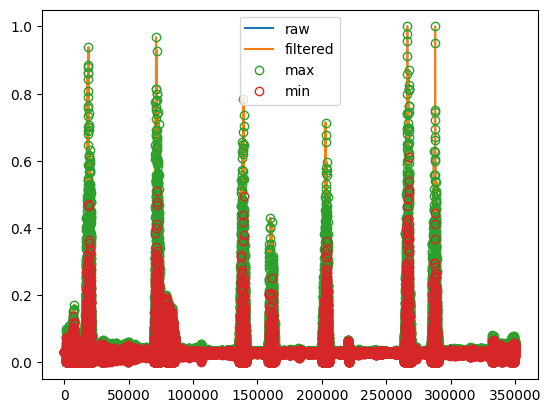

In [10]:
y = np.abs(y)
yFiltered = gaussian_filter1d(y, sigma=0.01)
yMax = signal.argrelmax(yFiltered)[0]
yMin = signal.argrelmin(yFiltered)[0]

plt.plot(y, label = 'raw')
plt.plot(yFiltered, label = 'filtered')
plt.plot(yMax, yFiltered[yMax], 'o', mfc= 'none', label = 'max')
plt.plot(yMin, yFiltered[yMin], 'o', mfc= 'none', label = 'min')
plt.legend()
plt.savefig('fig-sound.png', dpi = 300)

peaks.shape: (9,)
[ 18730  71261  73790 139188 159973 202932 266332 285845 287985]


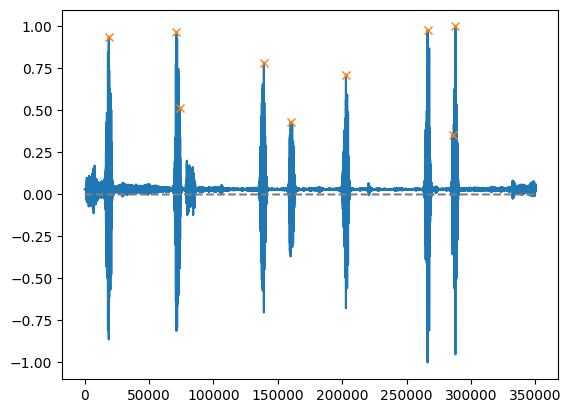

In [41]:
peaks, _ = find_peaks(y, distance=2000, prominence=0.7)

# stft_fps = 100
# frame_length_s = 0.08
# nperseg = int(frame_length_s * sr)
# nstep = sr // stft_fps
# _, _, spec = stft(y, nperseg=nperseg, noverlap=nperseg - nstep)
# min_width = int(round(0.5 * stft_fps))
# max_width = int(round(2 * stft_fps))
# width_step_size = int(round((max_width - min_width) / 10))
# width = np.arange(1, 550)
# peaks, _ = find_peaks_cwt(y, width, max_distances=width * 2)
print(f'peaks.shape: {peaks.shape}')
print(peaks)
plt.plot(y)
plt.plot(peaks, y[peaks], "x")
plt.plot(np.zeros_like(y), "--", color="gray")
plt.show()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

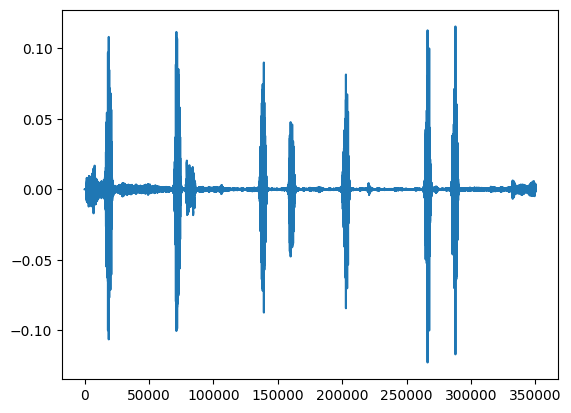

In [ ]:
from peakdetect import peakdetect

peaks = peakdetect(y, lookahead=2000, delta=2) 
# Lookahead is the distance to look ahead from a peak to determine if it is the actual peak. 
# Change lookahead as necessary 
higherPeaks = np.array(peaks[0])
lowerPeaks = np.array(peaks[1])
plt.plot(y)
plt.plot(higherPeaks[:,0], higherPeaks[:,1], 'ro')
plt.plot(lowerPeaks[:,0], lowerPeaks[:,1], 'ko')